
CAT Framework — Notebook 00
Purpose:
Establish deterministic research environment
Validate dataset integrity
Generate dataset profiling report

Mounted at /content/drive
Experiment Run: 20260306_124720
Dataset loaded: 100000
Load time: 0.266 seconds
Invalid country codes: 0
Invalid UUID: 0
Runtime: 33.21 seconds
Notebook 00 completed


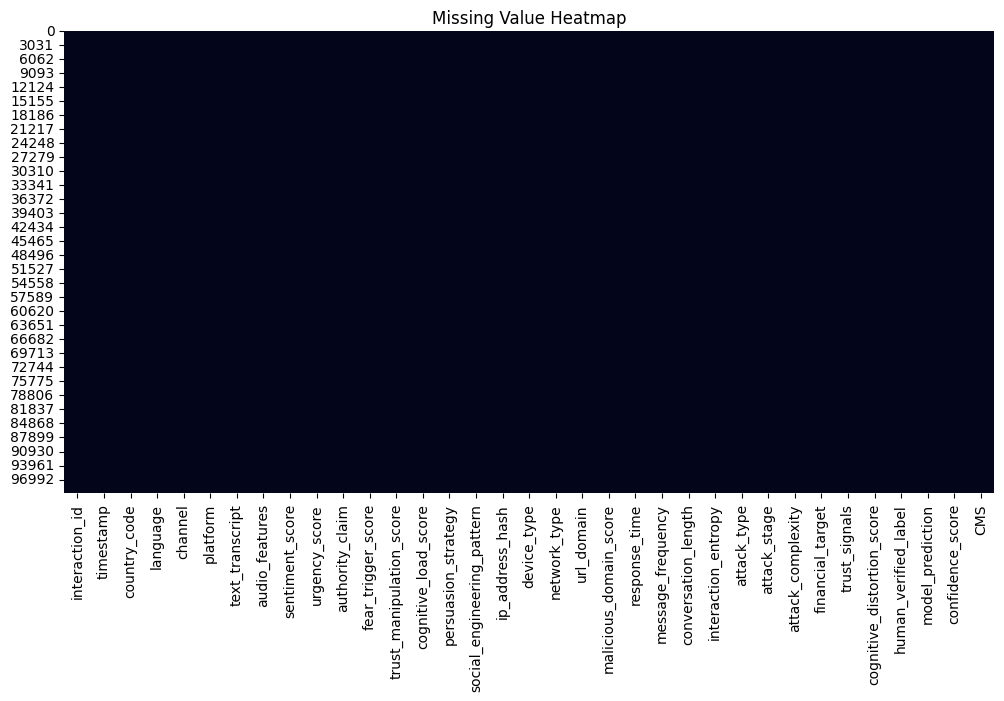

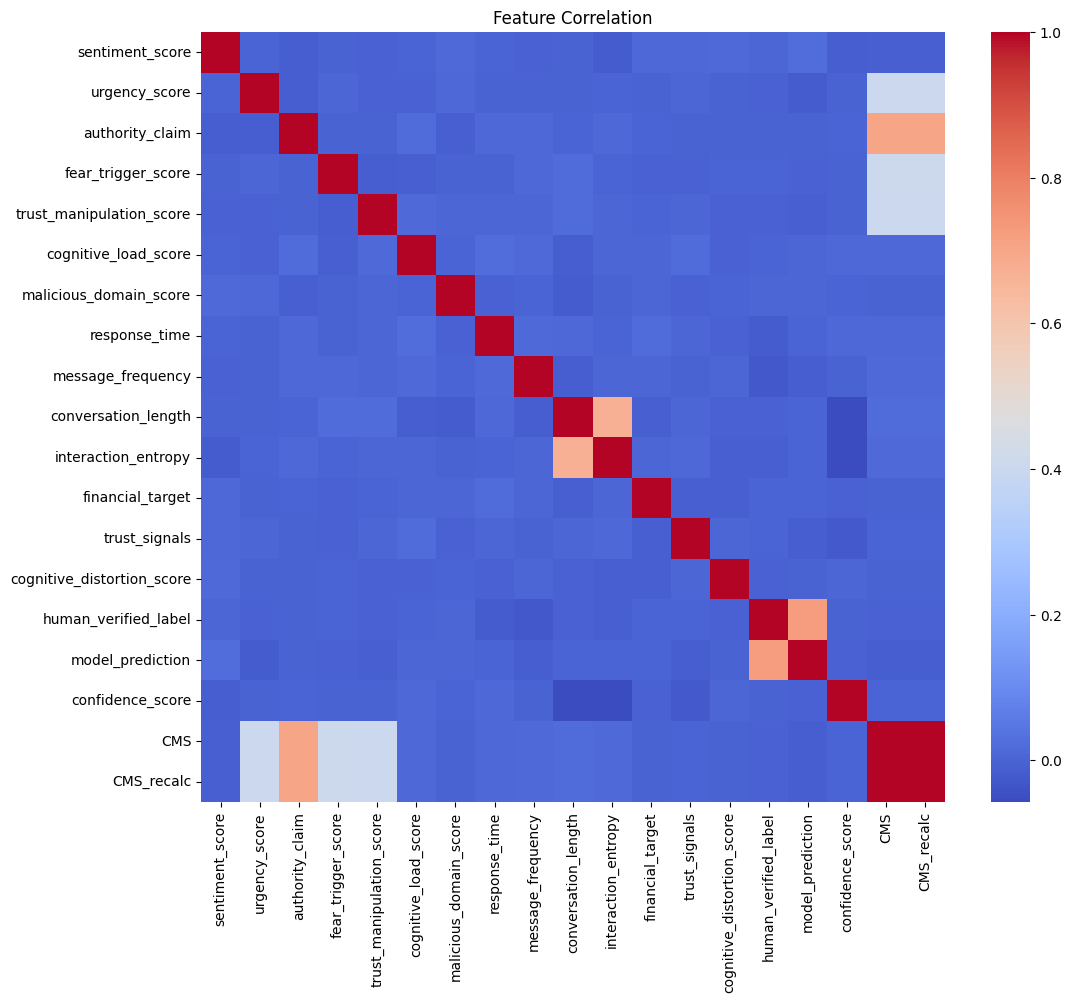

In [9]:
  # ===============================================================
  # NOTEBOOK 00 — WORLD ELITE CAT RESEARCH ENVIRONMENT
  # Cognitive Attack Topology Framework
  # ===============================================================

  !pip -q install pandas numpy torch pyarrow pydantic networkx \
  omegaconf scikit-learn matplotlib seaborn tqdm pycountry psutil

  import os
  import sys
  import json
  import uuid
  import time
  import torch
  import random
  import psutil
  import hashlib
  import pycountry
  import platform
  import subprocess
  import pandas as pd
  import numpy as np
  import seaborn as sns
  import matplotlib.pyplot as plt

  from pathlib import Path
  from datetime import datetime
  from tqdm import tqdm
  from omegaconf import OmegaConf
  from pydantic import BaseModel, validator

  from sklearn.ensemble import RandomForestClassifier
  from sklearn.feature_selection import mutual_info_classif

  from google.colab import drive

  # ===============================================================
  # NOTEBOOK DESCRIPTION
  # ===============================================================

  print("""
  CAT Framework — Notebook 00
  Purpose:
  Establish deterministic research environment
  Validate dataset integrity
  Generate dataset profiling report
  """)

  # ===============================================================
  # MOUNT DRIVE
  # ===============================================================

  drive.mount('/content/drive', force_remount=True)

  ROOT = Path("/content/drive/MyDrive/CAT_RESEARCH")
  ROOT.mkdir(parents=True, exist_ok=True)

  RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

  RUN_DIR = ROOT/"runs"/RUN_ID
  DATA_DIR = ROOT/"data"
  REPORT_DIR = RUN_DIR/"reports"
  PLOT_DIR = RUN_DIR/"plots"
  ENV_DIR = RUN_DIR/"environment"

  for p in [RUN_DIR,DATA_DIR,REPORT_DIR,PLOT_DIR,ENV_DIR]:
      p.mkdir(parents=True, exist_ok=True)

  print("Experiment Run:",RUN_ID)

  # ===============================================================
  # REPRODUCIBILITY
  # ===============================================================

  SEED = 42

  random.seed(SEED)
  np.random.seed(SEED)
  torch.manual_seed(SEED)

  if torch.cuda.is_available():
      torch.cuda.manual_seed_all(SEED)

  torch.backends.cudnn.deterministic=True
  torch.backends.cudnn.benchmark=False

  # save RNG states

  torch.save(torch.random.get_rng_state(),ENV_DIR/"torch_rng.pt")
  np.save(ENV_DIR/"numpy_rng.npy", np.array(np.random.get_state(), dtype=object))

  # ===============================================================
  # HARDWARE PROFILE
  # ===============================================================

  ram = psutil.virtual_memory().total/(1024**3)

  hardware = {

  "python_version":platform.python_version(),
  "platform":platform.platform(),
  "cpu_cores":psutil.cpu_count(),
  "ram_gb":round(ram,2),
  "torch_version":torch.__version__,
  "cuda_available":torch.cuda.is_available(),
  "cuda_version":torch.version.cuda,
  "cudnn_version":torch.backends.cudnn.version(),
  "timezone":time.tzname

  }

  if torch.cuda.is_available():
      hardware["gpu_name"]=torch.cuda.get_device_name(0)
      hardware["gpu_memory_gb"]=round(
          torch.cuda.get_device_properties(0).total_memory/1e9,2)

  with open(ENV_DIR/"hardware_profile.json","w") as f:
      json.dump(hardware,f,indent=4)

  # ===============================================================
  # DEPENDENCY LOCKFILE
  # ===============================================================

  req = subprocess.check_output(["pip","freeze"]).decode()

  with open(ENV_DIR/"requirements.txt","w") as f:
      f.write(req)

  # ===============================================================
  # CONFIG
  # ===============================================================

  config = OmegaConf.create({

  "version":"1.0",

  "dataset":{

  "name":"GCT_phase1_100k.parquet",
  "schema_version":"1.0"

  },

  "features":{

  "normalized_range":[0,1]

  }

  })

  OmegaConf.save(config,ENV_DIR/"config.yaml")

  # ===============================================================
  # DATASET VALIDATION
  # ===============================================================

  DATA_PATH = DATA_DIR/config.dataset.name

  if not DATA_PATH.exists():
      raise FileNotFoundError("Dataset missing:",DATA_PATH)

  start = time.time()

  df = pd.read_parquet(DATA_PATH)

  load_time = time.time()-start

  print("Dataset loaded:",len(df))
  print("Load time:",round(load_time,3),"seconds")

  # ===============================================================
  # DATASET CHECKSUM
  # ===============================================================

  with open(DATA_PATH,"rb") as f:
      checksum = hashlib.sha256(f.read()).hexdigest()

  file_size = os.path.getsize(DATA_PATH)

  dataset_meta = {

  "checksum":checksum,
  "file_size":file_size,
  "rows":len(df)

  }

  with open(REPORT_DIR/"dataset_metadata.json","w") as f:
      json.dump(dataset_meta,f,indent=4)

  # ===============================================================
  # ISO VALIDATION
  # ===============================================================

  iso_countries = {c.alpha_2 for c in pycountry.countries}

  invalid_country = df[~df["country_code"].isin(iso_countries)]

  print("Invalid country codes:",len(invalid_country))

  # ===============================================================
  # UUID VALIDATION
  # ===============================================================

  invalid_uuid = []

  for x in df["interaction_id"].head(10000):
      try:
          uuid.UUID(x)
      except:
          invalid_uuid.append(x)

  print("Invalid UUID:",len(invalid_uuid))

  # ===============================================================
  # MISSING VALUES
  # ===============================================================

  missing = df.isnull().mean()*100

  missing.to_csv(REPORT_DIR/"missing_values.csv")

  plt.figure(figsize=(12,6))
  sns.heatmap(df.isnull(),cbar=False)
  plt.title("Missing Value Heatmap")
  plt.savefig(PLOT_DIR/"missing_heatmap.png")


  # ===============================================================
  # ENTROPY CHECK
  # ===============================================================

  def entropy(text):

      probs = pd.Series(list(text)).value_counts(normalize=True)

      return -(probs*np.log2(probs)).sum()

  sample_entropy = entropy(df["text_transcript"].iloc[0])

  # ===============================================================
  # CMS VALIDATION
  # ===============================================================

  alpha=beta=gamma=delta=0.25

  df["CMS_recalc"]=(
  alpha*df["urgency_score"]+
  beta*df["fear_trigger_score"]+
  gamma*df["authority_claim"]+
  delta*df["trust_manipulation_score"]
  )

  cms_error=(df["CMS"]-df["CMS_recalc"]).abs().mean()

  # ===============================================================
  # CLASS DISTRIBUTION
  # ===============================================================

  class_dist = df["attack_type"].value_counts()

  class_dist.to_csv(REPORT_DIR/"class_distribution.csv")

  # ===============================================================
  # CORRELATION MATRIX
  # ===============================================================

  num=df.select_dtypes(include=np.number)

  corr=num.corr()

  plt.figure(figsize=(12,10))
  sns.heatmap(corr,cmap="coolwarm")
  plt.title("Feature Correlation")
  plt.savefig(PLOT_DIR/"correlation_matrix.png")

  # ===============================================================
  # FEATURE IMPORTANCE
  # ===============================================================

  if "human_verified_label" in df.columns:

      X=num.fillna(0)
      y=df["human_verified_label"]

      rf=RandomForestClassifier(n_estimators=100)

      rf.fit(X,y)

      imp=pd.DataFrame({

      "feature":X.columns,
      "importance":rf.feature_importances_

      }).sort_values("importance",ascending=False)

      imp.to_csv(REPORT_DIR/"feature_importance.csv")

  # ===============================================================
  # MUTUAL INFORMATION
  # ===============================================================

  if "human_verified_label" in df.columns:

      mi=mutual_info_classif(X,y)

      mi_df=pd.DataFrame({

      "feature":X.columns,
      "MI":mi

      }).sort_values("MI",ascending=False)

      mi_df.to_csv(REPORT_DIR/"mutual_information.csv")

  # ===============================================================
  # FINAL REPORT
  # ===============================================================

  report = {

  "rows":len(df),
  "cms_error":float(cms_error),
  "invalid_country_codes":int(len(invalid_country)),
  "invalid_uuid":len(invalid_uuid),
  "entropy_sample":float(sample_entropy),
  "dataset_checksum":checksum,
  "dataset_load_time":load_time,
  "run_id":RUN_ID

  }

  with open(REPORT_DIR/"dataset_report.json","w") as f:
      json.dump(report,f,indent=4)

  runtime = time.time()-start

  print("Runtime:",round(runtime,2),"seconds")

  print("Notebook 00 completed")